# Forensic Glass Classification: Machine Learning Analysis
**Course:** SCC 222 
**Student ID:** 39586421  

---

## Table of Contents
* [Data Preparation](#data-preparation)
* [K-Nearest Neighbours (KNN)](#k-nearest-neighbours)
* [Naïve Bayes (NB)](#naive-bayes)
* [Decision Trees (DT)](#decision-trees)
* [Evaluation & Results](#evaluation)

<a id="data-preparation"></a>
## Data Preparation
The **Glass Identification Database** contains 214 instances. Key steps in this section include:
* **Feature Scaling:** Since KNN is a distance-based algorithm, we use `StandardScaler` to ensure features like Refractive Index (small range) don't get overshadowed by Silicon (large range).
* **Data Leakage Prevention:** Note that the scaler is `.fit()` only on `X_train` to ensure the model has no knowledge of the test set distribution.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset 
# The dataset has an ID column, 9 features, and 1 class attribute
column_names = ['Id', 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']
df = pd.read_csv('glass.data', names=column_names)

# Drop the 'Id' column as it is just an identifier
df = df.drop('Id', axis=1)

# Separate the 9 features (X) and the 7 classes/types of glass (y) 
X = df.drop('Type', axis=1)
y = df['Type'].values

STUDENT_ID = 39322408

# Splits data into train and test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,          
    random_state=STUDENT_ID, # Uses ID as the seed for reproducibility 
    shuffle=True             # Ensures the random permutation required 
)
# Scale the features (for distance-based algorithms like KNN)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<a id="k-nearest-neighbours"></a>
## K Nearest Neighbours

**Euclidean Distance Formula:**
$$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$

In [2]:
import numpy as np
from collections import Counter

class CustomKNN:
    def __init__(self, k):
        """
        Initializes the KNN model.
        k: The number of nearest neighbors to consider.
        """
        self.k = k

    def fit(self, X_train, y_train):
        """
        'Trains' the model. For KNN, this simply means storing the training data.
        """
        # Ensure data is in numpy arrays for mathematical operations
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)

    def predict(self, X_test):
        """
        Predicts the class labels for the provided testing data.
        """
        X_test = np.array(X_test)
        # Predict the label for each sample in the test set
        predictions = [self._predict_single(x) for x in X_test]
        return np.array(predictions)

    def _predict_single(self, x):
        """
        Predicts the class label for a single test sample.
        """
        # Calculate Euclidean distances between the test point 'x' and all training points
        distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))

        # Get the indices of the 'k' training points with the smallest distances
        # np.argsort sorts the array and returns the indices
        k_indices = np.argsort(distances)[:self.k]

        # Extract the labels of these k nearest neighbors
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # Determine the most common class label among the neighbors
        most_common = Counter(k_nearest_labels).most_common(1)
        
        return most_common[0][0]

# Custom Accuracy Function 
def custom_accuracy(y_true, y_pred):
    """
    Calculates the accuracy of the predictions.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    correct_predictions = np.sum(y_true == y_pred)
    return correct_predictions / len(y_true)

<a id="naive-bayes"></a>
## Naive Bayes
**Gaussian Probability Density Function:**
$$P(x_i | y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)$$

In [3]:
import numpy as np
class CustomNaiveBayes:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.parameters = {}
        
        # Calculate mean, variance, and prior probability for each class
        for c in self.classes:
            X_c = X[y == c]
            self.parameters[c] = {
                'mean': np.mean(X_c, axis=0),
                # Added 1e-4 epsilon to variance to prevent division by zero errors during likelihood calculation
                'var': np.var(X_c, axis=0) + 1e-4,
                'prior': X_c.shape[0] / X.shape[0]
            }

    def _calculate_likelihood(self, class_val, x):
        # Gaussian Probability Density Function
        mean = self.parameters[class_val]['mean']
        var = self.parameters[class_val]['var']
        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def predict(self, X):
        y_pred = [self._predict_single(x) for x in X]
        return np.array(y_pred)

    def _predict_single(self, x):
        posteriors = []
        for c in self.classes:
            prior = np.log(self.parameters[c]['prior'])
            
            # Get the likelihoods array
            likelihoods = self._calculate_likelihood(c, x)
            
            # Add a tiny epsilon (1e-9) to prevent np.log(0.0)
            posterior = np.sum(np.log(likelihoods + 1e-9))
            
            posterior = prior + posterior
            posteriors.append(posterior)
            
        # Return the class with the highest posterior probability
        return self.classes[np.argmax(posteriors)]

<a id="decision-trees"></a>
## Decision Trees
**Shannon Entropy ($H$):**
$$H(y) = -\sum P(y_i) \log(P(y_i))$$

**Information Gain ($IG$):**
$$IG = H(parent) - H(children)$$

In [4]:
import numpy as np
from collections import Counter
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value # Class label if it's a leaf node

    def is_leaf_node(self):
        return self.value is not None

class CustomDecisionTree:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # Stopping criteria
        if depth >= self.max_depth or n_labels == 1 or n_samples < 2:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Find the best split
        feat_idxs =np.random.choice(n_features, n_features, replace=False)
        best_feat, best_thresh = self._best_split(X, y, feat_idxs)

        # Grow children recursively
        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return Node(value=self._most_common_label(y))
            
        left = self._build_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._build_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        return Node(best_feat, best_thresh, left, right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_thresh = None, None
        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            for thr in thresholds:
                gain = self._information_gain(y, X_column, thr)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = thr
        return split_idx, split_thresh

    def _information_gain(self, y, X_column, threshold):
        # Calculate parent Entropy
        parent_entropy = self._entropy(y)
        # Split data
        left_idxs, right_idxs = self._split(X_column, threshold)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0
        # Calculate weighted child Entropy
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r
        # Return Information Gain
        return parent_entropy - child_entropy

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs
    # Calculates Shannon Entropy to measure the impurity of the node.
    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log(p) for p in ps if p > 0])

    def _most_common_label(self, y):
        return Counter(y).most_common(1)[0][0]

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

<a id="evaluation"></a>
## Evaluating The Models
The models are assessed based on three metrics: **prediction accuracy**, **training time**, and **testing time**.

--- Evaluating K-Nearest Neighbour (KNN) ---
Accuracy: 0.5385
Train Time: 0.00000s | Test Time: 0.00200s


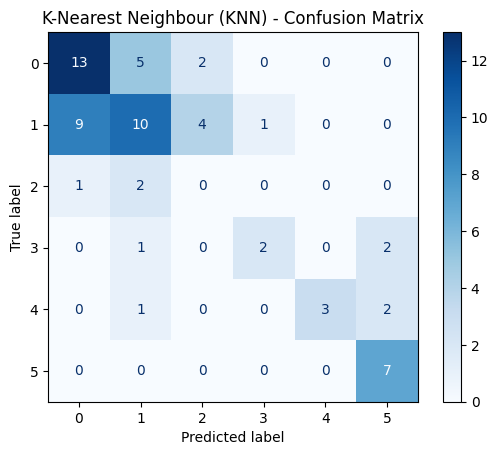



--- Evaluating Naïve Bayes (NB) ---
Accuracy: 0.4769
Train Time: 0.00151s | Test Time: 0.00753s


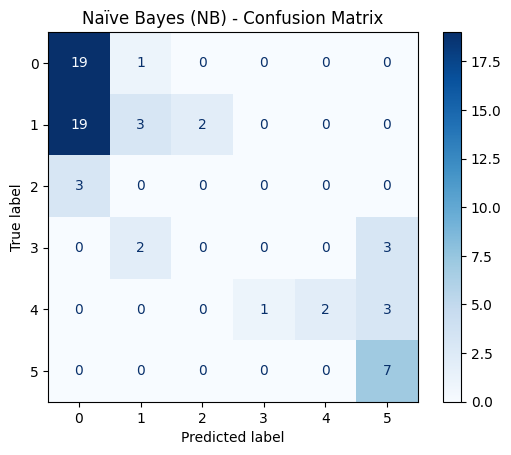



--- Evaluating Decision Tree (DT) ---
Accuracy: 0.5846
Train Time: 0.07725s | Test Time: 0.00000s


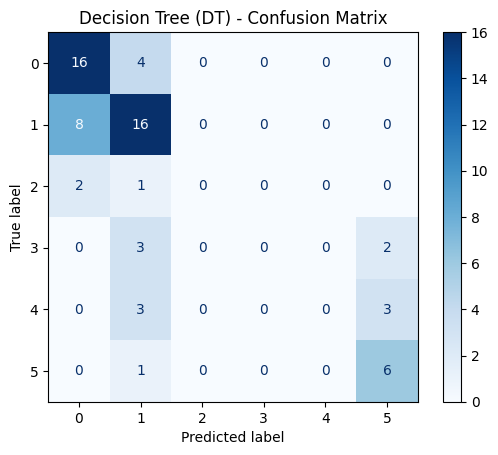



=== Final Results Summary ===
                    Model  Accuracy  Train Time (s)  Test Time (s)
K-Nearest Neighbour (KNN)  0.538462        0.000000       0.001999
         Naïve Bayes (NB)  0.476923        0.001506       0.007526
       Decision Tree (DT)  0.584615        0.077249       0.000000


In [5]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Initialise models
models = {
    "K-Nearest Neighbour (KNN)": CustomKNN(k=5),
    "Naïve Bayes (NB)": CustomNaiveBayes(),
    "Decision Tree (DT)": CustomDecisionTree(max_depth=10)
}

results = []

for name, model in models.items():
    print(f"--- Evaluating {name} ---")
    np.random.seed(42)
    # Measure Training Time
    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    end_train = time.time()
    train_time = end_train - start_train
    
    # Measure Testing Time
    start_test = time.time()
    y_pred = model.predict(X_test_scaled)
    end_test = time.time()
    test_time = end_test - start_test
    
    # Calculate Accuracy
    acc = custom_accuracy(y_test, y_pred)
    
    # Store results for report
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Train Time (s)": train_time,
        "Test Time (s)": test_time
    })
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Train Time: {train_time:.5f}s | Test Time: {test_time:.5f}s")
    
    # Display Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{name} - Confusion Matrix")
    plt.show()
    print("\n")

# Prints a summary table 
results_df = pd.DataFrame(results)
print("=== Final Results Summary ===")
print(results_df.to_string(index=False))